# Regularisation for Regression Models -  Data Science Portfolio - Mai Bui

In this notebook, we want to see how well does proximity to amenities predict self-reported health. As such, we use these dataset:

Dataset 1: Centraal Bureau voor de Statistek (2024). Nabijheid voorzieningen; afstand locatie, wijk- en buurtcijfers 2024 [Dataset]. CBS. https://www.cbs.nl/nl-nl/cijfers/detail/86134NED?q=wijk%20kaart#IndelingswijzigingWijkenEnBuurten_4
- This dataset provides data on proximity to amenities in different districts and neighborhoods across Dutch cities and towns. The data is filtered to show only Amsterdam districts and neighborhoods as independent variables/predictors of health outcome for the linear regression analysis and supervised machine learning model.


Dataset 2: GGD'en/CBS/RIVM (2024). Gezondheid per wijk en buurt; 2012/2016/2020/2022/2024 (indeling 2024) [Dataset]. Rijksinstituut voor Volksgezondheid en Milieu Ministerie van Volksgezondheid, Welzijn en Sport. https://buurtatlas.vzinfo.nl/
- This dataset provides data on self-reported health in different districts and neighborhoods across Dutch cities and towns. The data is filtered to show only Amsterdam districts and neighborhoods as dependent variables for the linear regression analysis and supervised machine learning model.

For the purpose of this notebook, we will use the already cleaned and merge dataset.


From the dataset provided, this analysis 22 predictors are distances (km) to amenities such as GP surgeries, supermarkets,  train stations, museums, and leisure facilities predict (self-reported) health outcomes of adults (18 and older) in Amsterdam.

- **Dataset:** A combination of proximity to amenities and reported health datasets
- **Target variable:** repeated health
- **Features:** distance to different types of amenities
- **Techniques applied:** Linear regression, ridge regularization


Ridge regularization is a way to prevent overfitting in linear models by adding a penalty term to the loss function. The loss function of a linear model is given by
$$
RSS(\beta) = \sum_{i=1}^{n}(y_i - x_i^T\beta)^2.
$$
The cost function for Ridge Regression is then
$$
J(\beta) = \sum_{i=1}^{n}(y_i - x_i^T\beta)^2 + \alpha\sum_{j=1}^{p}\beta_j^2,
$$
thus the linear model loss is augmented by a penalty term with the regularization parameter $\alpha$.

In this notebook, I will:
- Fit an OLS linear regression baseline to predict self-reported health from proximity to amenities
- Apply Ridge, Lasso, and Elastic Net regularisation to address multicollinearity among the distance features
- Use cross-validation to select the optimal regularisation strength (alpha) for each model
- Compare model performance (RMSE, R², bias) to see which regularisation approach generalises best
- Use bootstrap resampling to build confidence intervals around coefficients, showing how regularisation stabilises them
- Interpret which amenities are the strongest predictors of health using the Lasso-selected features

This notebook is an attempt at improving analysis from a previous research, which can be assessed here: https://docs.google.com/document/d/1hBwucpf_grdulaoBr4rGpxB9xBA9kXST3gAWzuF7tEs/edit?usp=sharing

# Dataset

In [1]:
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import statsmodels.api as sm


In [2]:
df = pd.read_csv("datasets/regularization_dataset.csv")
df

,area_name,municipality_name,region_type,Health_GP_Distance_km,Health_GP_Count_Within_1km,Health_GP_Count_Within_3km,Health_GP_Count_Within_5km,Health_GP_after_hours_Distance_km,Health_Pharmacy_Distance_km,Health_Hospital_incl_Distance_km,...,district_x,Name_clean_x,match,GEBIED_NAAM,18_en_ouder,18_tot_65,65_en_ouder,area_name_normalized,district_y,Name_clean_y
0,Amsterdam,Amsterdam,Gemeente,0.6,3.0,28.0,66.8,3.3,0.7,2.6,...,Other,amsterdam,gemeente amsterdam,Gemeente: Amsterdam,66.8,69.6,52.2,gemeente: amsterdam,Other,gemeente amsterdam
1,Haarlemmerbuurt,Amsterdam,Wijk,0.5,3.5,30.3,89.0,4.6,0.9,2.0,...,Other,haarlemmerbuurt,haarlemmerbuurt oost,Haarlemmerbuurt Oost,71.5,74.5,59.7,haarlemmerbuurt oost,Other,haarlemmerbuurt oost
2,Planciusbuurt-Noord,Amsterdam,Buurt,0.8,3.8,28.0,77.8,4.5,0.6,2.4,...,Other,planciusbuurtnoord,planciusbuurt noord,Planciusbuurt Noord,67.9,69.3,57.5,planciusbuurt noord,Other,planciusbuurt noord
3,Westelijke eilanden,Amsterdam,Buurt,0.9,1.5,26.9,75.6,4.8,0.9,2.4,...,Other,westelijke eilanden,westelijke eilanden,Westelijke eilanden,70.3,72.9,61.8,westelijke eilanden,Other,westelijke eilanden
4,Westerdokseiland,Amsterdam,Buurt,0.2,2.0,28.6,93.0,4.5,1.4,2.0,...,Other,westerdokseiland,westerdokseiland,Westerdokseiland,71.2,74.3,62.6,westerdokseiland,Other,westerdokseiland
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,Gein,Amsterdam,Wijk,0.8,0.7,4.3,22.9,3.6,0.9,3.6,...,Amsterdam Zuidoost,gein,gein noordoost,Gein Noordoost,73.0,74.6,69.1,gein noordoost,Amsterdam Zuidoost,gein noordoost
428,Gein 1,Amsterdam,Buurt,0.8,0.6,7.2,24.5,3.2,0.8,3.2,...,Amsterdam Zuidoost,gein 1,gein noordoost,Gein Noordoost,73.0,74.6,69.1,gein noordoost,Amsterdam Zuidoost,gein noordoost
429,Gein 2,Amsterdam,Buurt,0.8,1.0,3.5,21.8,3.6,0.8,3.6,...,Amsterdam Zuidoost,gein 2,gein noordoost,Gein Noordoost,73.0,74.6,69.1,gein noordoost,Amsterdam Zuidoost,gein noordoost
430,Gein 3,Amsterdam,Buurt,1.0,0.5,3.1,22.8,3.8,1.0,3.8,...,Amsterdam Zuidoost,gein 3,gein noordoost,Gein Noordoost,73.0,74.6,69.1,gein noordoost,Amsterdam Zuidoost,gein noordoost


In [3]:
regressors = [
    "Health_GP_Distance_km",
    "Health_GP_after_hours_Distance_km",
    "Health_Pharmacy_Distance_km",
    "Health_Hospital_incl_Distance_km",
    "Health_Hospital_excl_Distance_km",
    "Retail_Daily_grocery_Distance_to_large_supermarket_km",
    "Retail_Daily_grocery_Distance_to_other_daily_goods_km",
    "Hospitality_Cafes_Distance_to_café_e.d._km",
    "Hospitality_Restaurants_Distance_to_restaurant_km",
    "Traffic_transport_Distance_to_highway_ramp_km",
    "Traffic_transport_Train_stations_Distance_to_treinstations_totaal_km",
    "Traffic_transport_Train_stations_Distance_to_belangrijk_overstapstation_km",
    "Leisure_culture_Distance_to_bibliotheek_km",
    "Leisure_culture_Sport_Distance_to_indoor_pool_km",
    "Leisure_culture_Sport_Distance_to_ice_rink_km",
    "Leisure_culture_Museum_Distance_to_museum_km",
    "Leisure_culture_Performing_arts_(excl._festivals)_Distance_to_podiumkunsten_totaal_km",
    "Leisure_culture_Performing_arts_(excl._festivals)_Distance_to_music_venue_km",
    "Leisure_culture_Cinema_Distance_to_bioscoop_km",
    "Leisure_culture_Recreation_Distance_to_sauna_km",
    "Leisure_culture_Recreation_Distance_to_tanning_bed_km",
    "Leisure_culture_Recreation_Distance_to_attraction_km",
]
print(f"There is risk of overfitting as the number of observations Amsterdam neighbourhoods ({len(df.index)}) is small relative to {len(regressors)} features, so regularisation would be helpful in addressing this.")

There is risk of overfitting as the number of observations Amsterdam neighbourhoods (432) is small relative to 22 features, so regularisation would be helpful in addressing this.


These features are selected as distance is relevant to the question at hand.

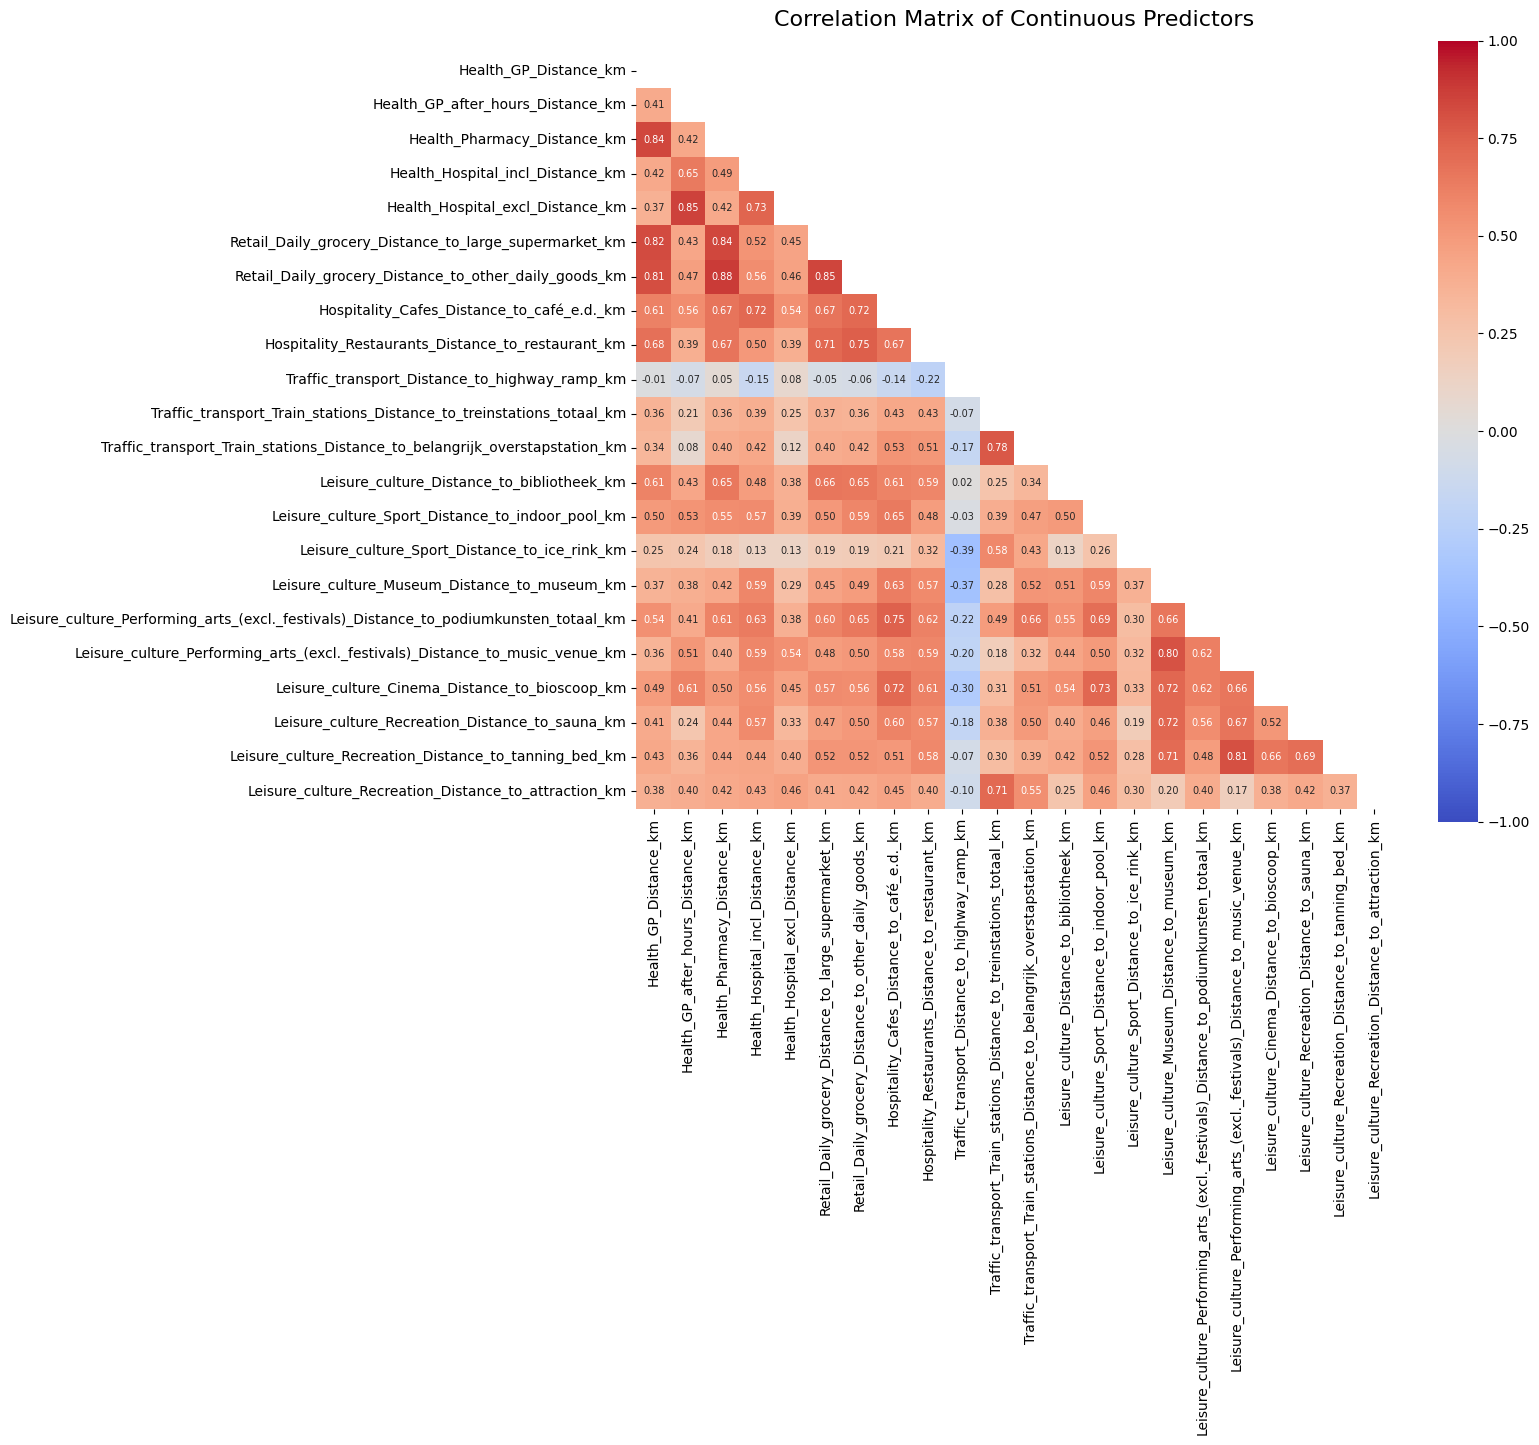

In [8]:
target = '18_en_ouder'
# Correlation heatmap for continuous predictors
plt.figure(figsize=(16, 14))
corr_matrix = df[regressors].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot_kws={"size": 7}, square=True)
plt.title('Correlation Matrix of Continuous Predictors', fontsize=16, pad=20)
plt.tight_layout()
plt.show()



Multicollinearity is expected in this data set because in a city the close distance to one facilities can also mean close distance to another. As multicollinearity is substantial in this dataset, regularisation is applied to address this.

# Preprocessing

Before fitting any models, the features and target are separated, a constant column is added for the intercept, and the data is cast to float so it works cleanly with both statsmodels and scikit-learn. The data is then split into training and test sets so model performance can be evaluated on unseen data rather than the data used to fit the model.

In [5]:
X = df[regressors]
y = df[target]

In [6]:
X = df[regressors]

# Add constant for intercept
X_with_const = sm.add_constant(X)

# Define target variable
y = df[target]

# Convert everything to float
X_with_const = X_with_const.astype(float)
y = y.astype(float)

df = pd.DataFrame.join(y, X_with_const)
df

,18_en_ouder,const,Health_GP_Distance_km,Health_GP_after_hours_Distance_km,Health_Pharmacy_Distance_km,Health_Hospital_incl_Distance_km,Health_Hospital_excl_Distance_km,Retail_Daily_grocery_Distance_to_large_supermarket_km,Retail_Daily_grocery_Distance_to_other_daily_goods_km,Hospitality_Cafes_Distance_to_café_e.d._km,...,Leisure_culture_Distance_to_bibliotheek_km,Leisure_culture_Sport_Distance_to_indoor_pool_km,Leisure_culture_Sport_Distance_to_ice_rink_km,Leisure_culture_Museum_Distance_to_museum_km,Leisure_culture_Performing_arts_(excl._festivals)_Distance_to_podiumkunsten_totaal_km,Leisure_culture_Performing_arts_(excl._festivals)_Distance_to_music_venue_km,Leisure_culture_Cinema_Distance_to_bioscoop_km,Leisure_culture_Recreation_Distance_to_sauna_km,Leisure_culture_Recreation_Distance_to_tanning_bed_km,Leisure_culture_Recreation_Distance_to_attraction_km
0,66.8,1.0,0.6,3.3,0.7,2.6,3.1,0.6,0.5,0.8,...,1.4,2.3,7.4,2.5,1.7,3.5,2.8,2.5,2.0,3.2
1,71.5,1.0,0.5,4.6,0.9,2.0,4.6,0.4,0.3,0.3,...,1.3,1.4,6.9,1.3,0.7,2.6,0.9,1.5,0.8,3.6
2,67.9,1.0,0.8,4.5,0.6,2.4,4.5,0.3,0.4,0.4,...,0.9,1.1,7.3,1.4,0.4,2.7,0.5,1.9,0.4,4.0
3,70.3,1.0,0.9,4.8,0.9,2.4,4.8,0.6,0.5,0.5,...,1.1,1.4,7.3,1.6,0.6,2.9,0.8,1.9,0.7,4.0
4,71.2,1.0,0.2,4.5,1.4,2.0,4.5,0.7,0.6,0.4,...,1.7,1.8,6.5,1.4,0.9,2.8,1.4,1.5,1.3,3.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,73.0,1.0,0.8,3.6,0.9,3.6,3.6,1.0,0.9,1.9,...,2.1,4.1,8.7,8.0,4.0,9.7,5.4,6.7,7.0,1.3
428,73.0,1.0,0.8,3.2,0.8,3.2,3.2,0.9,0.8,1.9,...,2.5,3.6,8.0,7.3,3.5,9.1,5.0,6.1,6.4,1.2
429,73.0,1.0,0.8,3.6,0.8,3.6,3.6,0.9,0.8,1.6,...,1.6,4.3,9.1,8.2,4.2,10.1,5.5,7.1,7.4,1.7
430,73.0,1.0,1.0,3.8,1.0,3.8,3.8,1.1,1.0,2.4,...,2.6,4.2,8.6,8.0,4.1,9.7,5.6,6.7,7.0,0.8


In [7]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_with_const, y, test_size=0.2, random_state=42
)

An 80/20 train-test split is used, which is a standard split size for a dataset of this size, and random_state=42 fixes the split so results are reproducible.

# OLS linear regression

Ordinary least squares (OLS) is fit first as a baseline. Because the predictors are highly collinear, OLS coefficients are expected to be large, unstable, and hard to interpret; this baseline is used for comparison to see how much regularisation improves on it.

In [11]:
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso

ols = LinearRegression()
ols.fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)

## Ridge

In [12]:
alphas = np.logspace(-5, 5, 300)

ridge_cv = RidgeCV(alphas=alphas, fit_intercept=True, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)

print(f"Optimal alpha: {ridge_cv.alpha_:.6f}")

Optimal alpha: 66.487878


In [13]:
# predict with the best Ridge model
y_pred_ridge = ridge_cv.predict(X_test)

## Lasso

In [14]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas=np.logspace(-5, 5, 300), cv=10, max_iter=50000, random_state=42)
lasso_cv.fit(X_train, y_train)
y_pred_lasso = lasso_cv.predict(X_test)

print(f"Lasso best alpha: {lasso_cv.alpha_:.6f}")
print(f"Non-zero coefficients: {np.sum(lasso_cv.coef_ != 0)} / {len(lasso_cv.coef_)}")


Lasso best alpha: 0.190957
Non-zero coefficients: 14 / 23


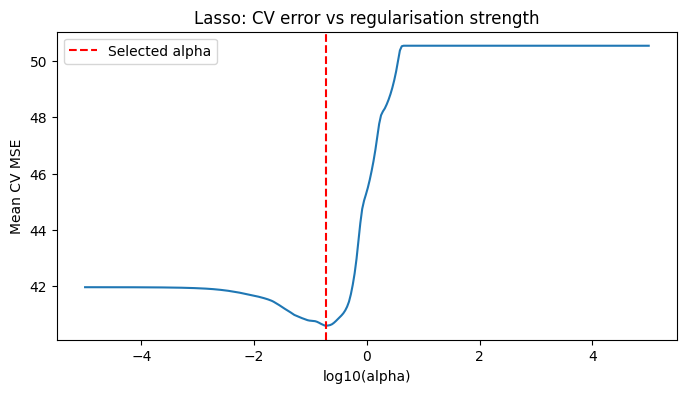

In [15]:
# For LassoCV, mse_path_ has shape (n_alphas, n_folds)
mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(np.log10(lasso_cv.alphas_), mean_mse)
plt.axvline(np.log10(lasso_cv.alpha_), color='red', linestyle='--', label='Selected alpha')
plt.xlabel('log10(alpha)'), plt.ylabel('Mean CV MSE')
plt.title('Lasso: CV error vs regularisation strength')
plt.legend(); plt.show()

The Lasso CV error curve shows a clear minimum around log10(alpha) ≈ -0.72, confirming that moderate regularisation improves generalisation over OLS. The alpha of 0.19 is a mild penalty, sitting in the moderate-regularisation zone rather than near zero (OLS) or near infinity (heavy shrinkage).

The sharp rise after the minimum demonstrates that Lasso is sensitive to over-regularisation as too high an alpha aggressively zeros out informative features, collapsing predictive performance. The flat  plateau at high alpha represents a null model predicting the mean for all neighbourhoods.

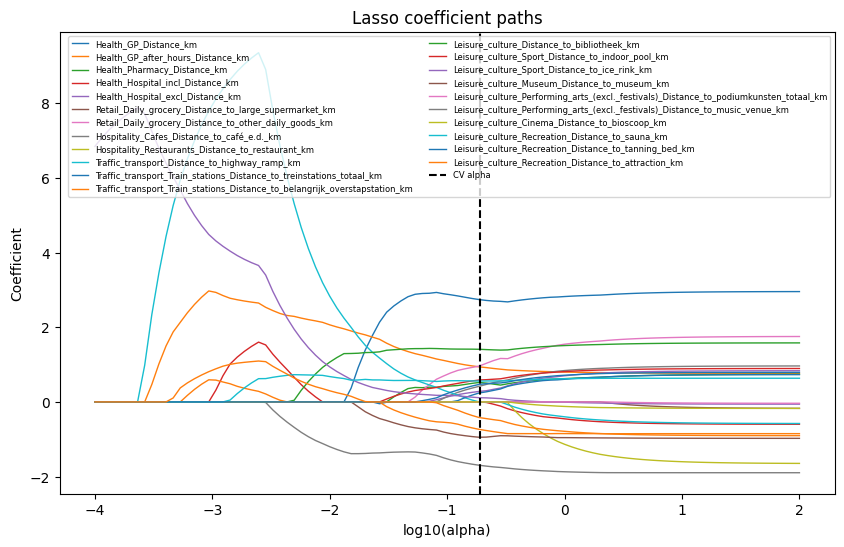

In [16]:
from sklearn.linear_model import lasso_path, ridge_regression

alphas_path = np.logspace(-4, 2, 100)
_, lasso_coef_path, _ = lasso_path(X_train, y_train, alphas=alphas_path)

plt.figure(figsize=(10, 6))
for i, name in enumerate(X_train.columns[1:]):  # skip const
    plt.plot(np.log10(alphas_path), lasso_coef_path[i+1], label=name, linewidth=1)
plt.axvline(np.log10(lasso_cv.alpha_), color='black', linestyle='--', label=f'CV alpha')
plt.xlabel('log10(alpha)')
plt.ylabel('Coefficient')
plt.title('Lasso coefficient paths')
plt.legend(fontsize=6, ncol=2)
plt.show()

The Lasso coefficient path plot illustrates why regularisation is necessary for this  dataset. At low alpha, coefficients are large and highly unstable features spike and cross erratically as the model struggles to distribute weight among correlated amenity distances. 

As alpha increases toward the CV-selected value, most coefficients shrink steadily to zero, with only a small subset  surviving. This confirms that the majority of the 22 features are redundant once multicollinearity is accounted for.

## Elastic net

In [17]:
from sklearn.linear_model import ElasticNetCV

# l1_ratio controls the mix: 0 = pure Ridge, 1 = pure Lasso
# Searching over multiple ratios lets CV pick the best blend
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]

enet_cv = ElasticNetCV(
    l1_ratio=l1_ratios,
    alphas=np.logspace(-4, 2, 100),
    cv=10,
    max_iter=50000,
    random_state=42
)
enet_cv.fit(X_train, y_train)
y_pred_enet = enet_cv.predict(X_test)

print(f"Elastic Net best alpha:    {enet_cv.alpha_:.6f}")
print(f"Elastic Net best l1_ratio: {enet_cv.l1_ratio_:.2f}")
print(f"Non-zero coefficients:     {np.sum(enet_cv.coef_ != 0)} / {len(enet_cv.coef_)}")

Elastic Net best alpha:    0.187382
Elastic Net best l1_ratio: 0.10
Non-zero coefficients:     21 / 23


Elastic Net combines Ridge's L2 penalty and Lasso's L1 penalty, controlled by `l1_ratio`. It is included to see whether a blend of the two performs better than either regularisation method alone, since it can retain Ridge's stability while still zeroing out some uninformative features like Lasso.

# Comparing model

In [18]:
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error, r2_score

print('Linear Model RMSE:',np.sqrt(mean_squared_error(y_test, y_pred_ols)))
print('Linear Model r²:',r2_score(y_test, y_pred_ols))
print('Linear Model bias:',np.mean(y_pred_ols-y_test))

print()
print('Ridge Model RMSE:',np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print('Ridge Model r²:',r2_score(y_test, y_pred_ridge))
print('Ridge Model bias:',np.mean(y_pred_ridge-y_test))

print()
print('Lasso Model RMSE:',np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print('Lasso Model r²:',r2_score(y_test, y_pred_lasso))
print('Lasso Model bias:',np.mean(y_pred_lasso-y_test))

print()
print('Elastic Net RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_enet)))
print('Elastic Net r²:  ', r2_score(y_test, y_pred_enet))
print('Elastic Net bias:', np.mean(y_pred_enet - y_test))


Linear Model RMSE: 6.434211008763645
Linear Model r²: 0.2144910205439392
Linear Model bias: 0.7952170311504221

Ridge Model RMSE: 6.238084727009118
Ridge Model r²: 0.2616486156865767
Ridge Model bias: 0.5492209783736705

Lasso Model RMSE: 6.256884456424333
Lasso Model r²: 0.25719156736015003
Lasso Model bias: 0.5012908064984469

Elastic Net RMSE: 6.2510926222689704
Elastic Net r²:   0.25856612751170194
Elastic Net bias: 0.5496543599557088


Ridge achieves the lowest RMSE and highest R², meaning it makes the most accurate predictions  on unseen neighbourhoods. It also substantially reduces the bias present in OLS (from 0.795 to 0.549), suggesting that shrinking correlated coefficients produces more calibrated predictions.

Lasso performs similarly to Ridge, but  worse on RMSE and R². However, to identify which amenities are genuinely predictive of health outcomes, Lasso is a good model as it zeros out redundant features.

The overall r^2 of ~0.26 is modest across all models, which is expected as self-reported health is influenced by many factors beyond physical proximity to amenities, such as income, age  distribution, and housing quality.

The modest improvement from OLS to regularised models suggests a limitation of the influence the features has. Amenity distances are downstream consequences of neighbourhood socioeconomic status rather than direct causes of health. This confounding limits how much any linear model can achieve with these features.

The most meaningful gain is in bias reduction (0.795 -> 0.499), indicating that regularisation produces better-calibrated predictions by suppressing the inflated,  unstable OLS coefficients caused by multicollinearity. 

Regularisation here is helps more with coefficient reliability than improving predictability. 

In [19]:
from sklearn.utils import resample
from sklearn.linear_model import ElasticNet

N_BOOT = 500
# X_train still has the statsmodels constant column, so feature names need to match
feature_names = list(X_train.columns)  # includes 'const' + 22 distance features

boot_ols   = np.zeros((N_BOOT, len(feature_names)))
boot_ridge = np.zeros((N_BOOT, len(feature_names)))
boot_lasso = np.zeros((N_BOOT, len(feature_names)))
boot_enet = np.zeros((N_BOOT, len(feature_names)))


for b in range(N_BOOT):
    X_b, y_b = resample(X_train, y_train, random_state=b)
    boot_ols[b]   = LinearRegression().fit(X_b, y_b).coef_
    boot_ridge[b] = Ridge(alpha=ridge_cv.alpha_).fit(X_b, y_b).coef_
    boot_lasso[b] = Lasso(alpha=lasso_cv.alpha_, max_iter=10000).fit(X_b, y_b).coef_
    boot_enet[b]  = ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, max_iter=10000).fit(X_b, y_b).coef_
    # ↑ replace 1.0 with lasso_cv.alpha_ once you've added LassoCV

# Compute 95% confidence intervals from the bootstrap distributions
ci_df = pd.DataFrame({
    'feature': feature_names,
    'ols_mean':     boot_ols.mean(axis=0),
    'ols_lo':       np.percentile(boot_ols,   2.5, axis=0),
    'ols_hi':       np.percentile(boot_ols,  97.5, axis=0),
    'ridge_mean':   boot_ridge.mean(axis=0),
    'ridge_lo':     np.percentile(boot_ridge, 2.5, axis=0),
    'ridge_hi':     np.percentile(boot_ridge,97.5, axis=0),
    'lasso_mean':   boot_lasso.mean(axis=0),
    'lasso_lo':     np.percentile(boot_lasso, 2.5, axis=0),
    'lasso_hi':     np.percentile(boot_lasso,97.5, axis=0),
}).set_index('feature').drop('const')  # drop intercept row for cleaner plot


Comparing Ridge & OLS to see how regularisation improve coefficient.

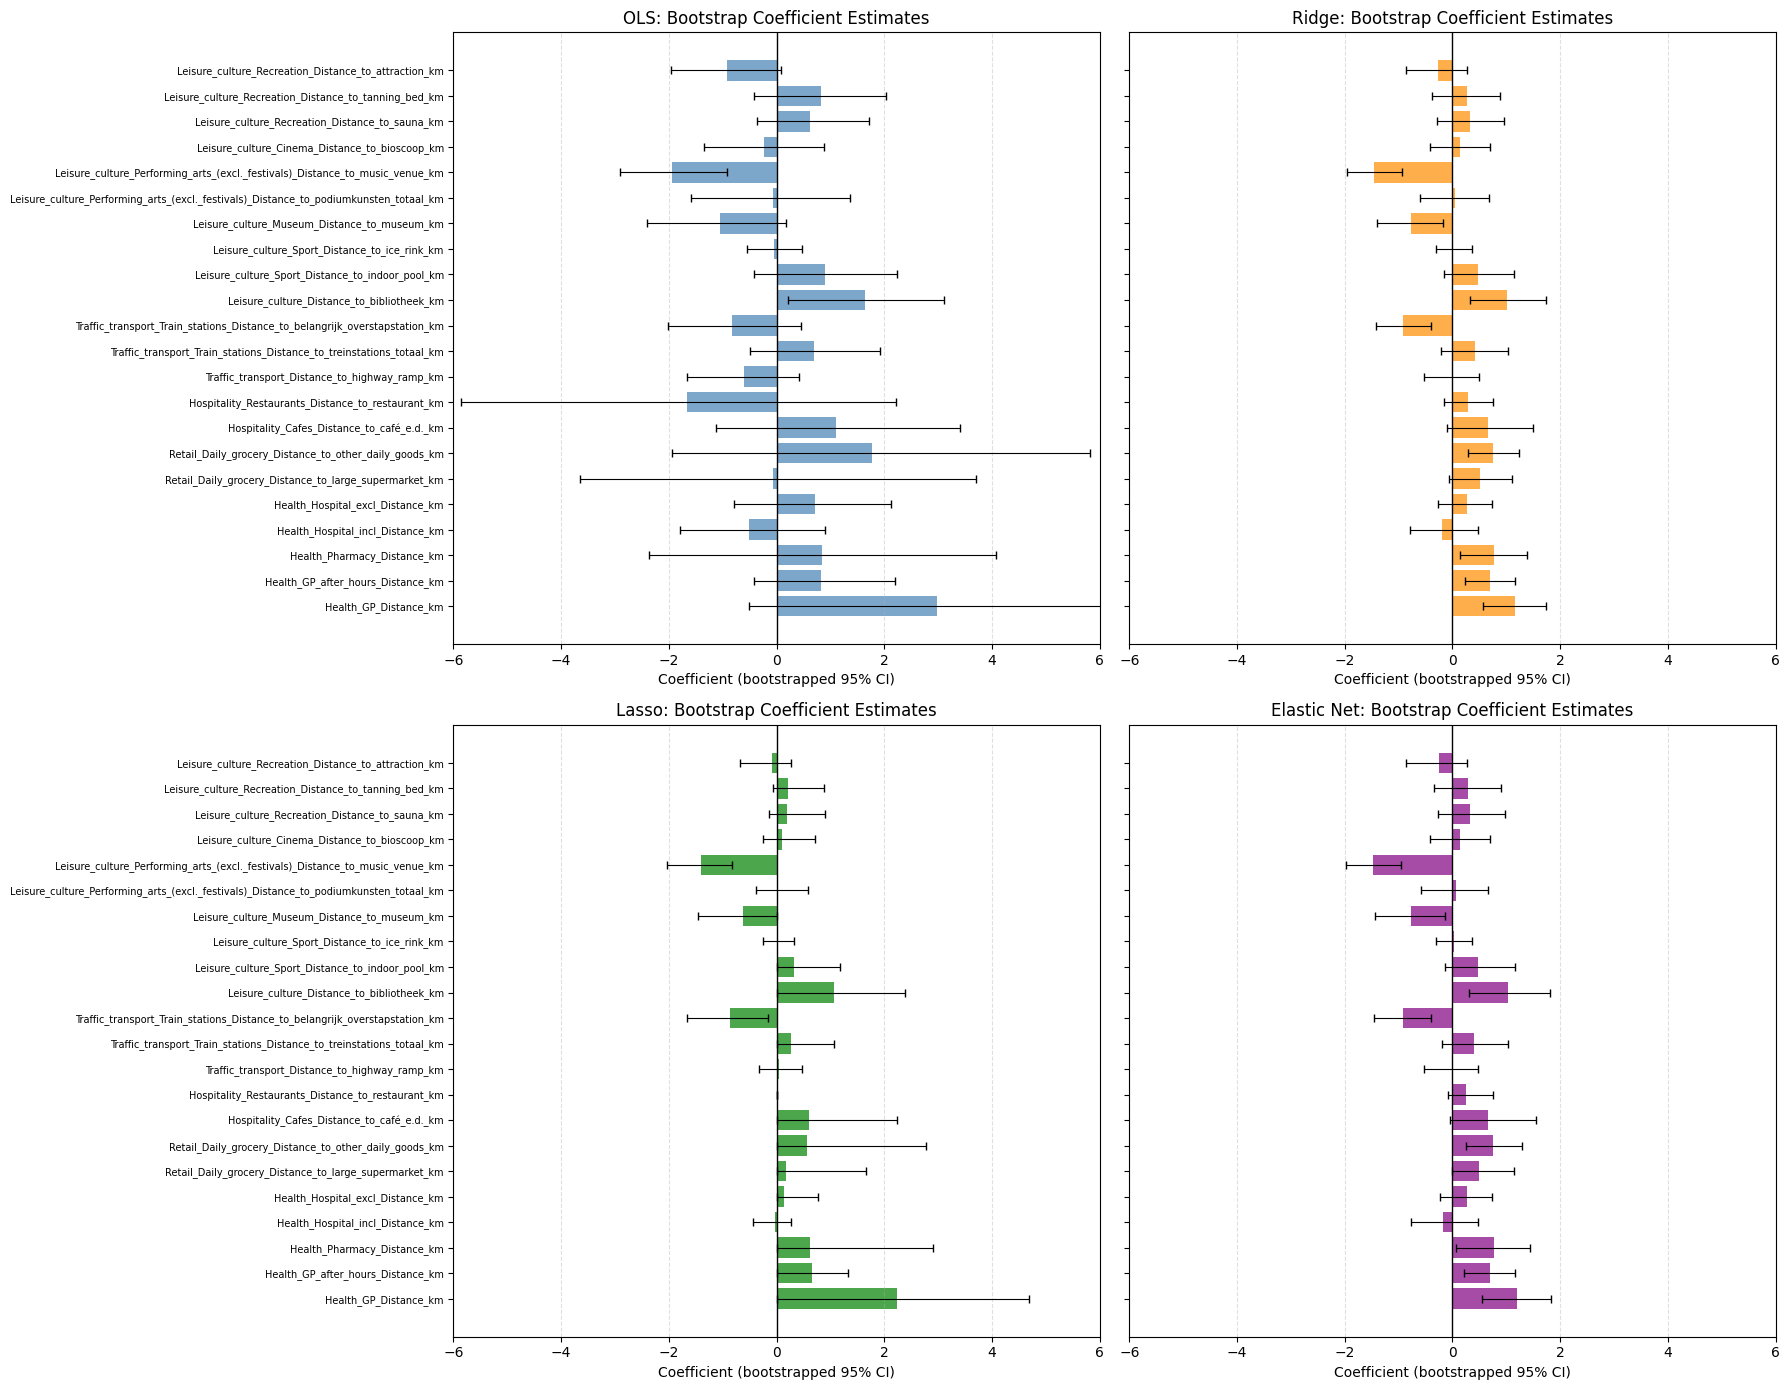

In [20]:
# Plot bootstrap CIs: OLS, Ridge, Lasso, and Elastic Net in 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharey=True)
axes = axes.flatten()

for idx, (ax, model, lo, hi, color, title) in enumerate([
    (axes[0], 'ols_mean',   'ols_lo',   'ols_hi',   'steelblue', 'OLS'),
    (axes[1], 'ridge_mean', 'ridge_lo', 'ridge_hi', 'darkorange','Ridge'),
    (axes[2], 'lasso_mean', 'lasso_lo', 'lasso_hi', 'green', 'Lasso'),
]):
    means = ci_df[model]
    errors = np.abs([
        means - ci_df[lo],   # lower error bar
        ci_df[hi] - means,   # upper error bar
    ])
    
    y_pos = np.arange(len(ci_df))
    ax.barh(y_pos, means, xerr=errors, color=color, alpha=0.7,
            error_kw=dict(ecolor='black', capsize=3, linewidth=0.8))
    ax.axvline(0, color='black', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ci_df.index, fontsize=7)
    ax.set_xlabel('Coefficient (bootstrapped 95% CI)')
    ax.set_title(f'{title}: Bootstrap Coefficient Estimates')
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')

# For the fourth subplot, we need to compute Elastic Net bootstrap CI
# Use the boot_enet array already computed
enet_ci_df = pd.DataFrame({
    'feature': feature_names,
    'enet_mean':    boot_enet.mean(axis=0),
    'enet_lo':      np.percentile(boot_enet, 2.5, axis=0),
    'enet_hi':      np.percentile(boot_enet, 97.5, axis=0),
}).set_index('feature').drop('const')

ax = axes[3]
means = enet_ci_df['enet_mean']
errors = np.abs([
    means - enet_ci_df['enet_lo'],
    enet_ci_df['enet_hi'] - means,
])

y_pos = np.arange(len(enet_ci_df))
ax.barh(y_pos, means, xerr=errors, color='purple', alpha=0.7,
        error_kw=dict(ecolor='black', capsize=3, linewidth=0.8))
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(enet_ci_df.index, fontsize=7)
ax.set_xlabel('Coefficient (bootstrapped 95% CI)')
ax.set_title('Elastic Net: Bootstrap Coefficient Estimates')
ax.grid(True, linestyle='--', alpha=0.4, axis='x')

# Set common x-axis limits for all subplots to (-6, 6)
for ax in axes:
    ax.set_xlim(-6, 6)

plt.tight_layout()
plt.show()


OLS  coefficients have wide, often uninformative CI, making interpretation unreliable. Regularision reduces this, producing narrower CIs. This shows how regularisation improve coefficient power and interprebility.

Ridge & Elastic net have most narrow CIs. However, we want to really drill in the features that are strong in predicting health. As such, we are going with Lasso.

In [21]:

# Create a series of coefficients, drop zeros, sort by absolute size
lasso_coefs = pd.Series(lasso_cv.coef_, index=X_train.columns).drop('const')
nonzero = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)

print(f"Non-zero coefficients: {len(nonzero)} / {len(lasso_coefs)}")
print()
print(nonzero.round(4))

Non-zero coefficients: 14 / 22

Health_GP_Distance_km                                                           2.7814
Leisure_culture_Performing_arts_(excl._festivals)_Distance_to_music_venue_km   -1.2450
Leisure_culture_Distance_to_bibliotheek_km                                      1.1139
Health_GP_after_hours_Distance_km                                               0.8151
Traffic_transport_Train_stations_Distance_to_belangrijk_overstapstation_km     -0.7304
Leisure_culture_Museum_Distance_to_museum_km                                   -0.6108
Retail_Daily_grocery_Distance_to_other_daily_goods_km                           0.5532
Hospitality_Cafes_Distance_to_café_e.d._km                                      0.4398
Leisure_culture_Sport_Distance_to_indoor_pool_km                                0.3048
Health_Pharmacy_Distance_km                                                     0.2516
Traffic_transport_Train_stations_Distance_to_treinstations_totaal_km            0.1831
Leisure_cul

Lasso retained 14 of 22 features, zeroing out 8 entirely. The zeroed features, including  distance to highway, ice rink, cinema, sauna, tanning bed, attraction, restaurant, and performing arts venues, are effectively deemed uninformative by the model once other features are accounted for.

The Lasso results suggest that cultural and leisure amenities are stronger predictors of health than healthcare facility proximity. This maybe because these amenities are proxies for socioeconomic status, which is a stronger determinant of health than physical access to healthcare alone.

This intepretation is in light of Lasso Model's metric as the self-report health RMSE is 6.257. Although it look moderate, given the STD of 7.14, the model’s typical prediction error is almost as large as the natural variation in the data, meaning that model is only slightly better than a naive model that predicts the mean for everyone.

The variance in health is only 25.72% explained by proximity to amenities, and the model slight predicts people's health as better, with a bias of 0.501.



In [22]:
df["18_en_ouder"].describe()

count    432.000000
mean      68.737963
std        7.145443
min       46.000000
25%       63.800000
50%       69.900000
75%       74.300000
max       83.000000
Name: 18_en_ouder, dtype: float64

## Conclusion

Across OLS, Ridge, Lasso, and Elastic Net, regularisation consistently reduced prediction bias and produced more stable, interpretable coefficients than plain OLS, though it only modestly improved raw prediction accuracy (RMSE, R²). Ridge gave the best overall predictive performance, while Lasso, by zeroing out 8 of the 22 features, highlighted cultural and leisure amenities as stronger predictors of self-reported health than proximity to healthcare facilities. However, with the model explaining only about 26% of the variance in health, and an RMSE close to the target's own standard deviation, amenity proximity alone is a weak predictor of health. This is likely because these amenities are, at best, proxies for underlying neighbourhood socioeconomic status rather than direct causes of health, which limits what any linear model can achieve with these features alone.